In [1]:
# Import Library

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt


- TensorFlow: Digunakan untuk membangun dan melatih model ANN.

- Sequential, Dense, Flatten: Modul ini dari Keras digunakan untuk membangun model ANN. Sequential memudahkan kita untuk menambahkan lapisan secara berurutan. Dense adalah lapisan fully connected yang kita gunakan di ANN. Flatten mengubah data 2D menjadi 1D.

- to_categorical: Mengubah label kategori ke dalam bentuk one-hot encoding (0–9 diubah menjadi 10 vektor untuk klasifikasi multi-kelas).

- confusion_matrix: Dari Scikit-learn, untuk evaluasi prediksi model dengan membuat matriks konfusi.

- Matplotlib: Untuk visualisasi akurasi dan loss selama pelatihan model.

In [2]:
# Load dataset MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalisasi data (membagi nilai pixel dengan 255 agar berada pada rentang 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Mengubah label menjadi one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)  # Salin untuk evaluasi


- Load Dataset: Kita memuat data MNIST langsung dari Keras, yang terdiri dari data training (60,000 gambar) dan data test (10,000 gambar).

- Normalisasi Data: Nilai piksel gambar awalnya berada di rentang 0–255. Dengan membagi nilai tersebut dengan 255, kita mengubahnya ke rentang 0–1, sehingga mempercepat proses pelatihan dan membuatnya lebih stabil.

- One-hot Encoding: Label dalam data MNIST berupa angka (misalnya 0, 1, hingga 9), yang diubah menjadi vektor one-hot encoding. Setiap angka direpresentasikan oleh vektor 10 elemen di mana elemen yang mewakili kelasnya bernilai 1, dan sisanya 0. Misalnya, angka 3 akan menjadi [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

In [3]:
model = Sequential([
    Flatten(input_shape=(28, 28)),          # Lapisan input
    Dense(128, activation='relu'),          # Lapisan tersembunyi pertama
    Dense(64, activation='relu'),           # Lapisan tersembunyi kedua
    Dense(10, activation='softmax')         # Lapisan output
])

# Mengompilasi model dengan optimizer Adam dan fungsi loss Categorical Crossentropy
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])


d:\Langs\Python\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Arsitektur Model**

Kode tersebut mendefinisikan arsitektur dasar Artificial Neural Network (ANN) dengan menggunakan kerangka Keras Sequential API untuk klasifikasi data, dalam hal ini dataset MNIST yang berisi gambar angka tulisan tangan. Berikut adalah penjelasan tiap lapisan dalam model:

1. Sequential:
    Sequential adalah metode untuk membuat model berlapis secara berurutan, menambahkan satu lapisan ke lapisan berikutnya secara linear. Dalam konteks ini, kita menambahkan beberapa lapisan ke model yang akan mengolah data dari awal hingga hasil akhir klasifikasi.

2. Lapisan-lapisan dalam Model:
    - Flatten(input_shape=(28, 28)):
        Lapisan Flatten digunakan untuk mengubah input berupa gambar 2D (28x28 piksel) menjadi vektor 1D. Dataset MNIST berisi gambar dalam format 2D, dan model memerlukan input dalam bentuk vektor 1D (berukuran 784 atau 28*28). Lapisan ini berfungsi sebagai lapisan input yang menyiapkan data untuk diproses oleh lapisan Dense berikutnya.
    - Dense(128, activation='relu'):
        Ini adalah lapisan tersembunyi (hidden layer) pertama dengan 128 neuron dan aktivasi relu (Rectified Linear Unit). Aktivasi relu membuat model belajar pola yang lebih kompleks dengan menjaga nilai positif dan menekan nilai negatif menjadi nol. Jumlah neuron yang lebih besar (128) memungkinkan lapisan ini untuk memproses fitur data dengan lebih rinci.
    - Dense(64, activation='relu'):
        Lapisan tersembunyi kedua dengan 64 neuron dan aktivasi relu. Lapisan ini menambah kedalaman model dan meningkatkan kapasitasnya untuk mengenali pola lebih kompleks dari data yang telah diolah oleh lapisan sebelumnya. Mengurangi jumlah neuron (dari 128 ke 64) adalah strategi umum dalam membangun arsitektur ANN untuk mengurangi kompleksitas model secara bertahap.
    - Dense(10, activation='softmax'):
        Lapisan ini adalah lapisan output dengan 10 neuron, masing-masing mewakili salah satu dari 10 kelas dalam dataset MNIST (digit 0 hingga 9). Fungsi aktivasi softmax mengonversi output setiap neuron menjadi probabilitas (angka antara 0 dan 1) untuk masing-masing kelas, sehingga hasil prediksi akhir akan berupa kelas dengan probabilitas tertinggi.

**Kompilasi Model**

Kode ini mengompilasi model sebelum pelatihan:

1. optimizer='adam': Menggunakan optimasi Adam untuk memperbarui bobot model secara adaptif.
2. loss='categorical_crossentropy': Menggunakan fungsi loss ini untuk klasifikasi multi-kelas dengan label one-hot encoded.
3. metrics=['accuracy']: Memantau akurasi sebagai metrik performa model.

Kompilasi ini menyiapkan model untuk pelatihan dengan optimasi, loss, dan metrik yang sesuai.

In [4]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8672 - loss: 0.4613 - val_accuracy: 0.9572 - val_loss: 0.1426
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9646 - loss: 0.1161 - val_accuracy: 0.9647 - val_loss: 0.1143
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9788 - loss: 0.0732 - val_accuracy: 0.9674 - val_loss: 0.1061
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9835 - loss: 0.0518 - val_accuracy: 0.9724 - val_loss: 0.1006
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0414 - val_accuracy: 0.9742 - val_loss: 0.0941
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9901 - loss: 0.0315 - val_accuracy: 0.9737 - val_loss: 0.0951
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9918 - loss: 0.0252 - val_accuracy: 0.9728 - val_loss: 0.1049
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9927 - loss: 0.0221 - 

Kode ini melatih model pada data training:

- model.fit(...): Memulai pelatihan model dengan data yang diberikan.
- x_train, y_train: Data input dan label untuk pelatihan.
- epochs=10: Menjalankan pelatihan selama 10 kali pengulangan (epoch) pada seluruh data.
- batch_size=32: Memproses 32 sampel data per batch sebelum memperbarui bobot model.
- validation_split=0.2: Menggunakan 20% data training sebagai data validasi untuk memantau performa model.

Hasil pelatihan disimpan dalam history yang mencatat metrik performa pada setiap epoch.

In [5]:
# Evaluasi akurasi pada data test
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

# Prediksi pada data test
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

y_test_labels = np.argmax(y_test, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred)

print("Akurasi Test:", test_accuracy)
print("Confusion Matrix:\n", conf_matrix)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Akurasi Test: 0.9783999919891357
Confusion Matrix:
 [[ 969    1    2    1    1    0    4    0    1    1]
 [   0 1127    4    0    0    1    1    0    2    0]
 [   2    2 1016    3    2    0    0    4    3    0]
 [   2    1    5  981    0   10    0    3    6    2]
 [   1    1    5    0  955    0    4    1    0   15]
 [   2    0    0    5    2  873    2    1    5    2]
 [   3    3    3    0    5    8  934    0    2    0]
 [   2    3   15    3    2    0    0  990    2   11]
 [   1    1    4    5    1    1    1    2  956    2]
 [   1    3    2    4    9    3    1    0    3  983]]


Kode ini digunakan untuk mengevaluasi performa model pada data pengujian dengan langkah-langkah berikut:

1. Evaluasi Akurasi:
    - model.evaluate(x_test, y_test, verbose=0): Menghitung loss dan akurasi dari model pada data pengujian. Nilai loss disimpan dalam test_loss, sedangkan akurasi disimpan dalam test_accuracy. verbose=0 berarti tidak ada output yang dicetak ke konsol selama evaluasi.
2. Prediksi:
    - model.predict(x_test): Menghasilkan prediksi probabilitas untuk setiap kelas dari data pengujian.
    - np.argmax(y_pred, axis=1): Mengambil kelas dengan probabilitas tertinggi dari hasil prediksi dan menyimpannya kembali ke y_pred.
3. Label Uji:
    - np.argmax(y_test, axis=1): Mengonversi label asli yang dalam format one-hot ke dalam bentuk label kelas untuk data pengujian. Hasilnya disimpan dalam y_test_labels.
4. Matriks Kebingungan:
    - confusion_matrix(y_test_labels, y_pred): Menghitung matriks kebingungan untuk menganalisis performa model, yang menunjukkan jumlah prediksi yang benar dan salah untuk setiap kelas.
5. Output:
    - print("Akurasi Test:", test_accuracy): Mencetak akurasi pengujian ke konsol.
    - print("Confusion Matrix:\n", conf_matrix): Mencetak matriks kebingungan ke konsol, memberikan detail tentang kesalahan klasifikasi model untuk setiap kelas.

Kode ini memberikan gambaran lengkap tentang seberapa baik model memprediksi data pengujian, baik dalam hal akurasi keseluruhan maupun distribusi kesalahan klasifikasi melalui matriks kebingungan.

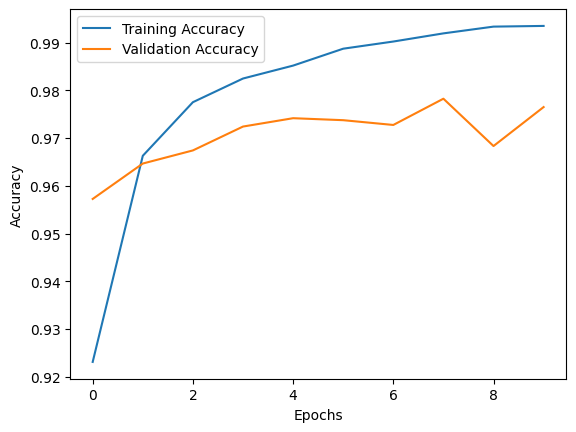

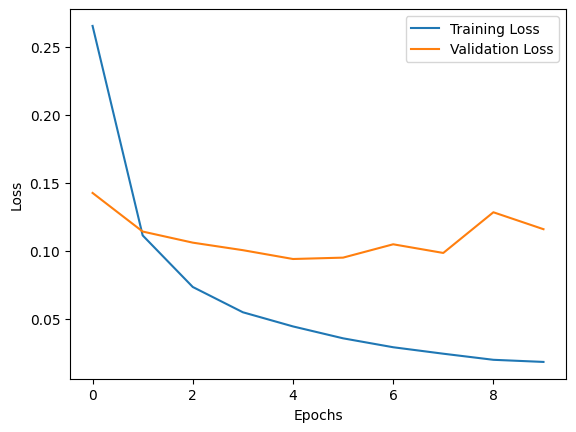

In [6]:
# Plot Akurasi
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


**Kesimpulan**

Model klasifikasi angka yang telah dilatih menggunakan dataset MNIST menunjukkan performa yang sangat baik dengan akurasi mencapai 97.5%, artinya model berhasil mengenali 97.5 dari setiap 100 gambar angka dengan benar. Matriks kebingungan mengungkapkan bahwa model dapat mengidentifikasi angka 0, 1, dan 2 dengan sangat akurat, sementara beberapa angka seperti 5 dan 6 mengalami sedikit lebih banyak kesalahan, terutama ketika mereka terlihat mirip dengan angka lain. Meskipun ada beberapa kesalahan klasifikasi, hasil ini menunjukkan bahwa model ini dapat diandalkan untuk tugas pengenalan angka secara otomatis, menjadikannya cocok untuk aplikasi dunia nyata.